# CMP461 Pattern Recognition - Midterm Project
## Phase 2: MLP (Multi-Layer Perceptron) Comparative Analysis

**Author:** Efe Yaşar  
**Student ID:** 210408030 

--- 

### Objective / Amaç
Implementing 5 different MLP architectures and comparing them across core metrics: Accuracy, Precision, Recall, and F1-Score. We will also visualize the learning curves and classification success for each.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

RESULTS_DIR = "results/mlp"
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs("models", exist_ok=True)

data = np.load("preprocessed_data.npz")
X_train, y_train = data["X_train"], data["y_train"]
X_val, y_val = data["X_val"], data["y_val"]
X_test, y_test = data["X_test"], data["y_test"]

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

input_dim = X_train_flat.shape[1]
classes = ["Cats", "Dogs", "Snakes"]

/Users/efe/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
def build_mlp(config):
    model = models.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    for units in config['hidden_layers']:
        model.add(layers.Dense(units, activation=config['activation']))
        if config.get('dropout'):
            model.add(layers.Dropout(config['dropout']))
    model.add(layers.Dense(3, activation='softmax'))
    opt = getattr(optimizers, config['optimizer'])(learning_rate=0.001)
    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

experiments = [
    {"name": "MLP_V1_Shallow", "hidden_layers": [128], "activation": "relu", "optimizer": "Adam"},
    {"name": "MLP_V2_Deep", "hidden_layers": [256, 128, 64], "activation": "relu", "optimizer": "Adam"},
    {"name": "MLP_V3_Tanh_RMS", "hidden_layers": [128, 128], "activation": "tanh", "optimizer": "RMSprop"},
    {"name": "MLP_V4_Wide_SGD", "hidden_layers": [512], "activation": "sigmoid", "optimizer": "SGD"},
    {"name": "MLP_V5_Optimized", "hidden_layers": [256, 128], "activation": "relu", "optimizer": "Adam", "dropout": 0.2}
]

🚀 Training MLP_V1_Shallow...
Epoch 1/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.3702 - loss: 11.0674 - val_accuracy: 0.3489 - val_loss: 4.2657
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3983 - loss: 3.5573 - val_accuracy: 0.3756 - val_loss: 5.1702
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4281 - loss: 3.9723 - val_accuracy: 0.4356 - val_loss: 1.7311
Epoch 4/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4527 - loss: 2.7589 - val_accuracy: 0.4178 - val_loss: 2.6502
Epoch 5/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4562 - loss: 3.2366 - val_accuracy: 0.4378 - val_loss: 2.4859
Epoch 6/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5519 - loss: 1.4079 - val_accuracy: 0.3822 - val_loss: 4.1809
Epoch 7/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4397 - loss: 4.0152 - val_accuracy: 0.3889 - val_loss: 1.8979
Epoch 8/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6004 - loss: 1.1

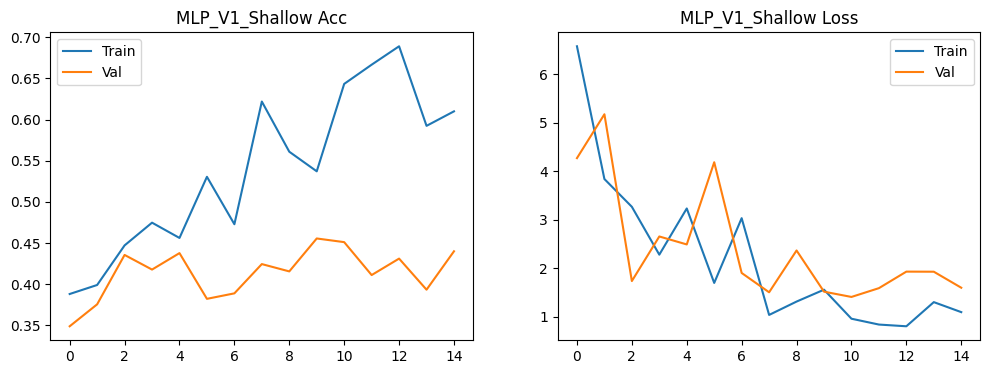

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


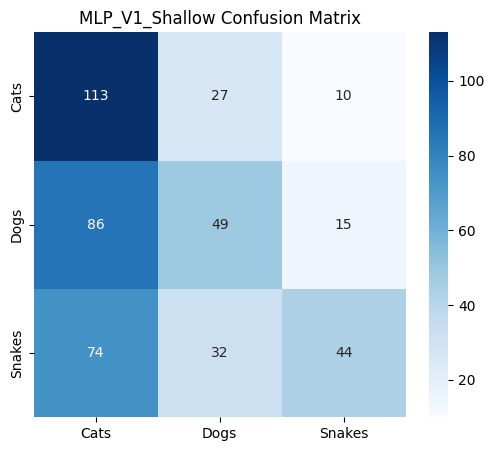

🚀 Training MLP_V2_Deep...
Epoch 1/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.3245 - loss: 5.9319 - val_accuracy: 0.4489 - val_loss: 1.4915
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.4662 - loss: 1.3382 - val_accuracy: 0.4089 - val_loss: 1.3352
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.4350 - loss: 1.4877 - val_accuracy: 0.4378 - val_loss: 1.0940
Epoch 4/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.5012 - loss: 1.1518 - val_accuracy: 0.4356 - val_loss: 1.5596
Epoch 5/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.5351 - loss: 1.0724 - val_accuracy: 0.4556 - val_loss: 1.1217
Epoch 6/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.5846 - loss: 0.9564 - val_accuracy: 0.4267 - val_loss: 1.3204
Epoch 7/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.5417 - loss: 1.0274 - val_accuracy: 0.4622 - val_loss: 1.1808
Epoch 8/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.6108 - loss: 0.8469 

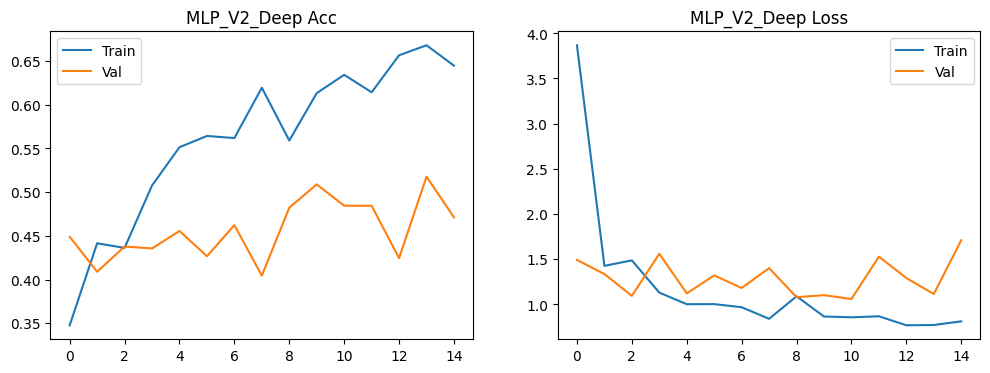

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


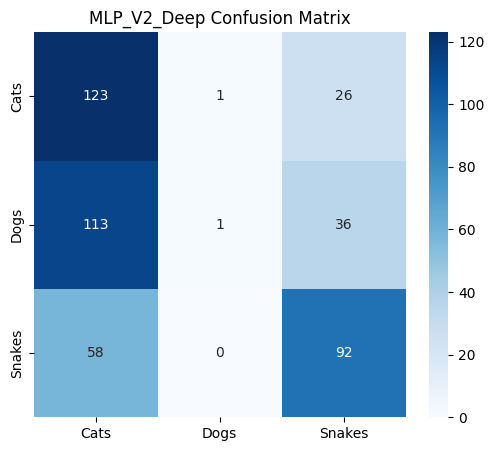

🚀 Training MLP_V3_Tanh_RMS...
Epoch 1/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.3247 - loss: 1.4831 - val_accuracy: 0.3333 - val_loss: 1.2098
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3264 - loss: 1.1473 - val_accuracy: 0.3333 - val_loss: 1.1443
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3401 - loss: 1.1255 - val_accuracy: 0.3333 - val_loss: 1.1233
Epoch 4/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3361 - loss: 1.1174 - val_accuracy: 0.3333 - val_loss: 1.1013
Epoch 5/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3276 - loss: 1.1156 - val_accuracy: 0.3333 - val_loss: 1.1334
Epoch 6/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3368 - loss: 1.1118 - val_accuracy: 0.3333 - val_loss: 1.1209
Epoch 7/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3330 - loss: 1.1138 - val_accuracy: 0.3333 - val_loss: 1.1155
Epoch 8/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3278 - loss: 1.1

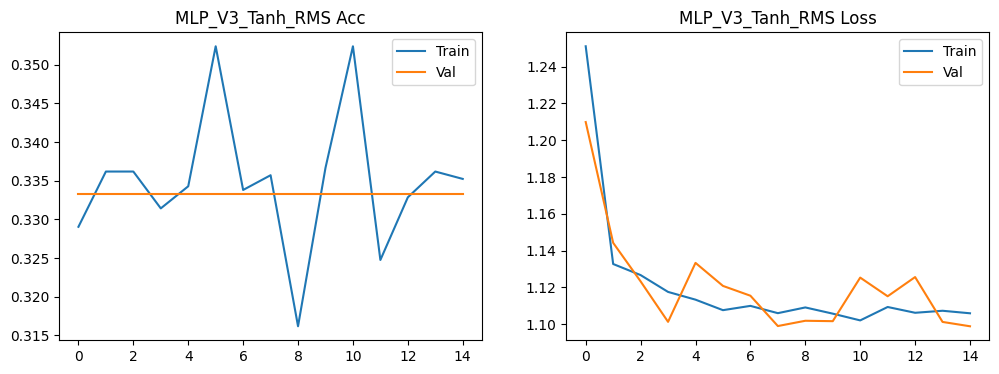

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


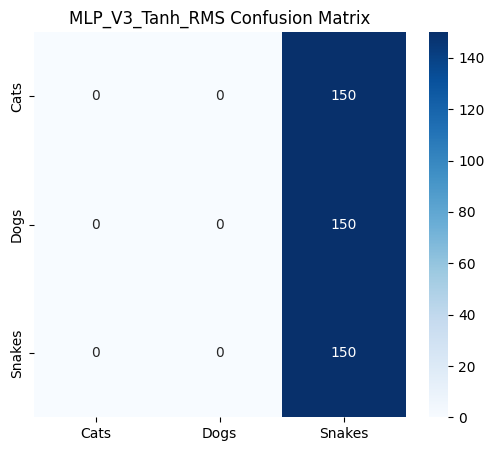

🚀 Training MLP_V4_Wide_SGD...
Epoch 1/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.3667 - loss: 1.1582 - val_accuracy: 0.3889 - val_loss: 1.0911
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.3805 - loss: 1.0864 - val_accuracy: 0.3600 - val_loss: 1.1065
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.4158 - loss: 1.0720 - val_accuracy: 0.4044 - val_loss: 1.0668
Epoch 4/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.4592 - loss: 1.0543 - val_accuracy: 0.4178 - val_loss: 1.0638
Epoch 5/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.4791 - loss: 1.0406 - val_accuracy: 0.4711 - val_loss: 1.0489
Epoch 6/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.5033 - loss: 1.0290 - val_accuracy: 0.4556 - val_loss: 1.0482
Epoch 7/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.4838 - loss: 1.0310 - val_accuracy: 0.4778 - val_loss: 1.0403
Epoch 8/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.4978 - loss: 1.0

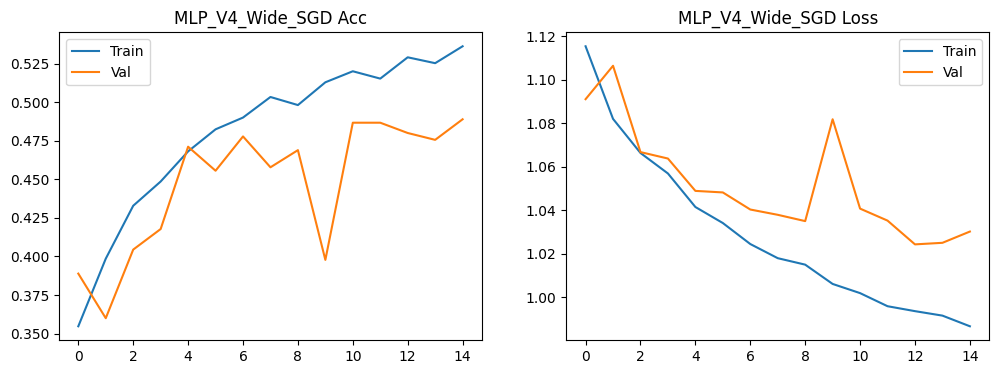

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


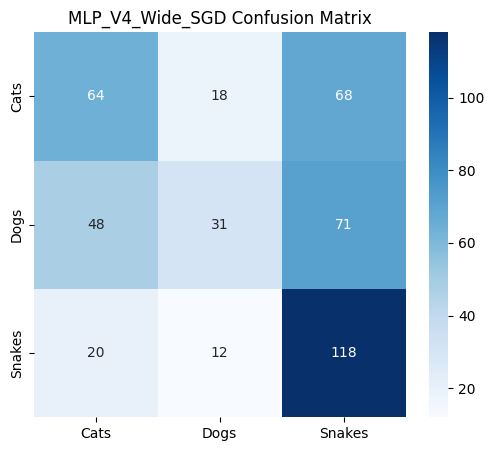

🚀 Training MLP_V5_Optimized...
Epoch 1/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.3133 - loss: 13.3862 - val_accuracy: 0.3667 - val_loss: 1.1168
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.3616 - loss: 1.5573 - val_accuracy: 0.3333 - val_loss: 1.0915
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.3584 - loss: 1.0938 - val_accuracy: 0.4022 - val_loss: 1.0653
Epoch 4/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.3484 - loss: 1.0825 - val_accuracy: 0.3867 - val_loss: 1.0699
Epoch 5/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.3584 - loss: 1.0854 - val_accuracy: 0.3400 - val_loss: 1.0971
Epoch 6/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.3666 - loss: 1.0877 - val_accuracy: 0.3867 - val_loss: 1.0733
Epoch 7/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.3745 - loss: 1.0909 - val_accuracy: 0.4578 - val_loss: 1.0435
Epoch 8/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.3869 - loss: 1

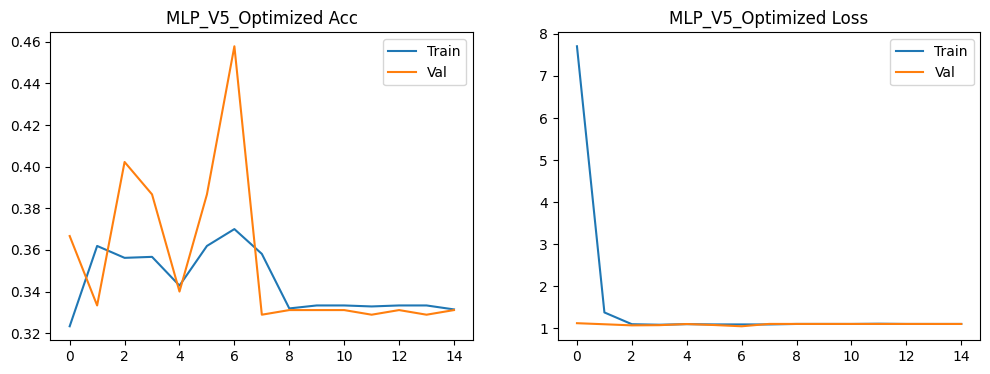

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


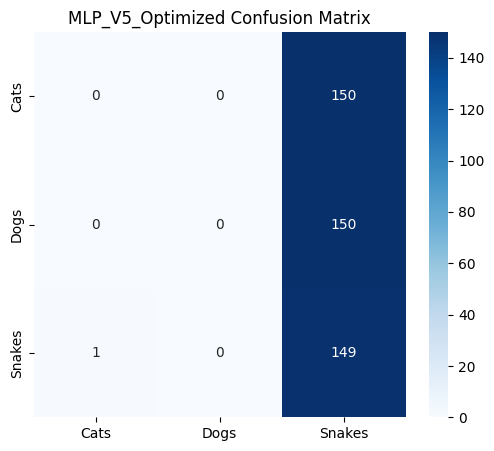

,Model,Test Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro)
0,MLP_V1_Shallow,0.457778,0.501768,0.457778,0.438650
1,MLP_V2_Deep,0.480000,0.505257,0.480000,0.390825
2,MLP_V3_Tanh_RMS,0.333333,0.111111,0.333333,0.166667
3,MLP_V4_Wide_SGD,0.473333,0.484063,0.473333,0.442531
4,MLP_V5_Optimized,0.331111,0.110616,0.331111,0.165832


In [3]:
results = []
for config in experiments:
    print(f"🚀 Training {config['name']}...")
    model = build_mlp(config)
    history = model.fit(X_train_flat, y_train, validation_data=(X_val_flat, y_val), epochs=15, batch_size=32, verbose=1)
    
    # Visualizing History
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1); plt.plot(history.history['accuracy'], label='Train'); plt.plot(history.history['val_accuracy'], label='Val'); plt.legend(); plt.title(f"{config['name']} Acc")
    plt.subplot(1, 2, 2); plt.plot(history.history['loss'], label='Train'); plt.plot(history.history['val_loss'], label='Val'); plt.legend(); plt.title(f"{config['name']} Loss")
    plt.savefig(f"{RESULTS_DIR}/{config['name']}_history.png")
    plt.show()

    # Prediction and Metrics
    y_pred = np.argmax(model.predict(X_test_flat), axis=1)
    p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)
    acc = np.mean(y_pred == y_test)
    results.append({"Model": config['name'], "Test Accuracy": acc, "Precision (Macro)": p, "Recall (Macro)": r, "F1-Score (Macro)": f1})
    
    # Confusion Matrix Plot
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
    plt.title(f"{config['name']} Confusion Matrix")
    plt.savefig(f"{RESULTS_DIR}/{config['name']}_cm.png")
    plt.show()
    
    model.save(f"models/{config['name']}.h5")

df_res = pd.DataFrame(results)
df_res.to_csv(f"{RESULTS_DIR}/mlp_results.csv", index=False)
display(df_res)